In [17]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder


In [18]:
#LOAD DATASET
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [19]:
#DATA PREPROCESSING
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


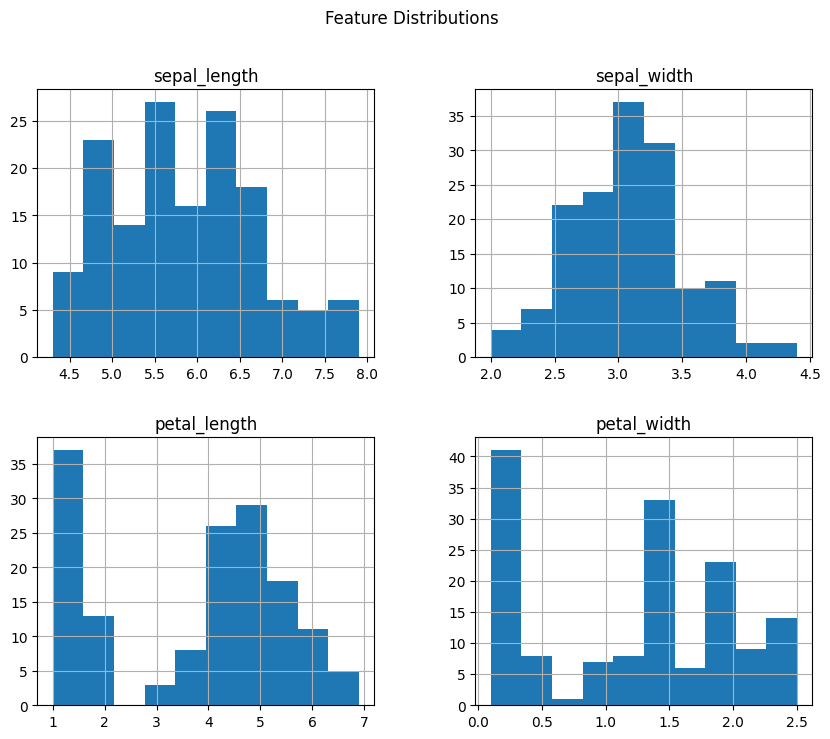

In [20]:
#DATA VISUALIZATION
#HISTOGRAMS
df.hist(figsize=(10,8))

plt.suptitle("Feature Distributions")
plt.show()

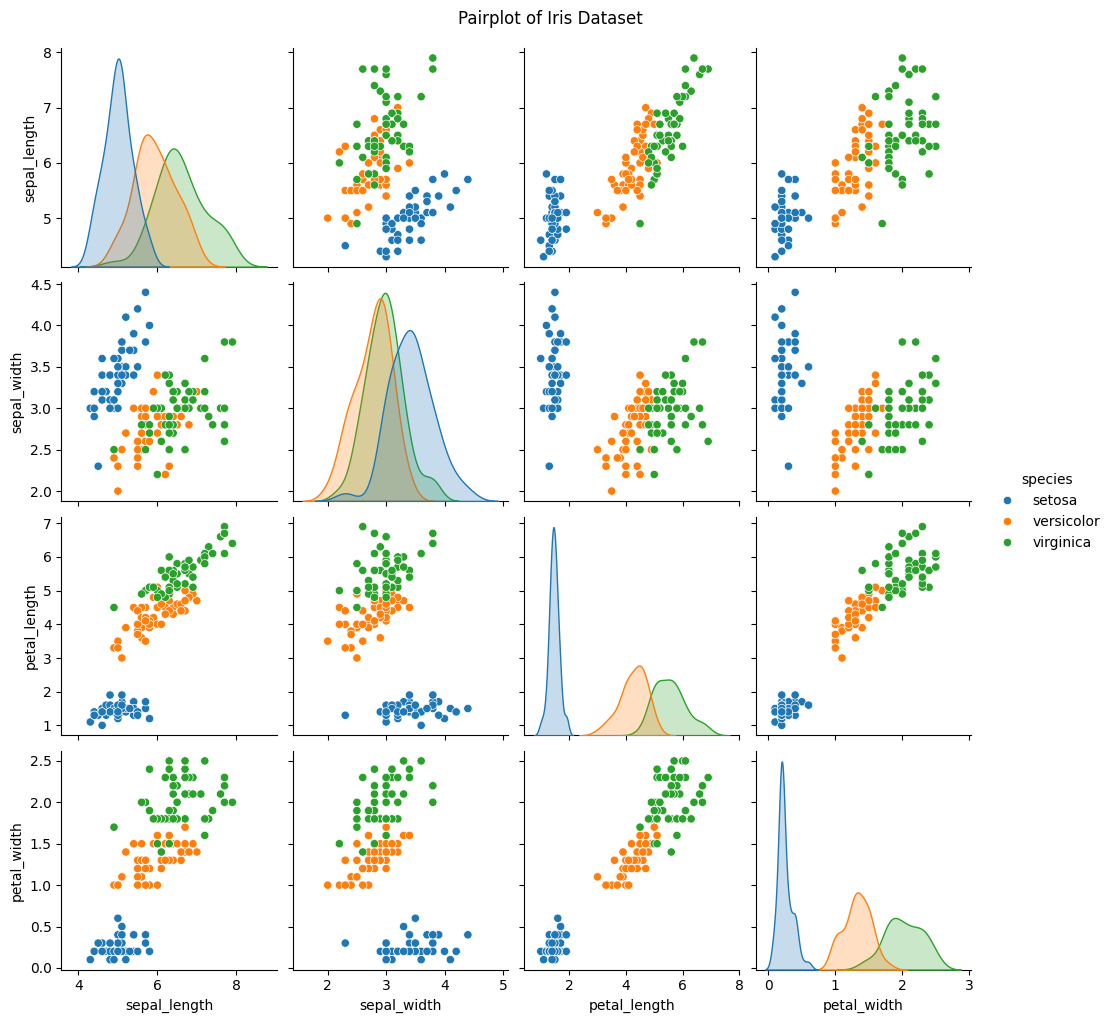

In [21]:
# PAIRPLOT
sns.pairplot(df, hue='species')

plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

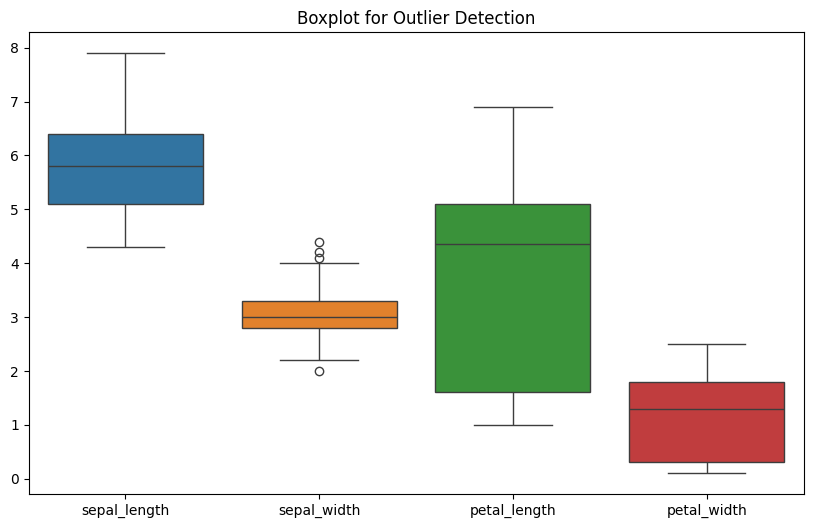

In [22]:
# BOXPLOTS
plt.figure(figsize=(10,6))

sns.boxplot(data=df.drop('species', axis=1))

plt.title("Boxplot for Outlier Detection")
plt.show()


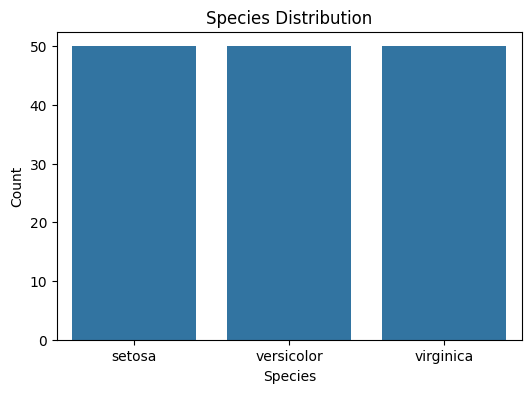

In [23]:
# SPECIES DISTRIBUTION
plt.figure(figsize=(6,4))

sns.countplot(x='species', data=df)

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

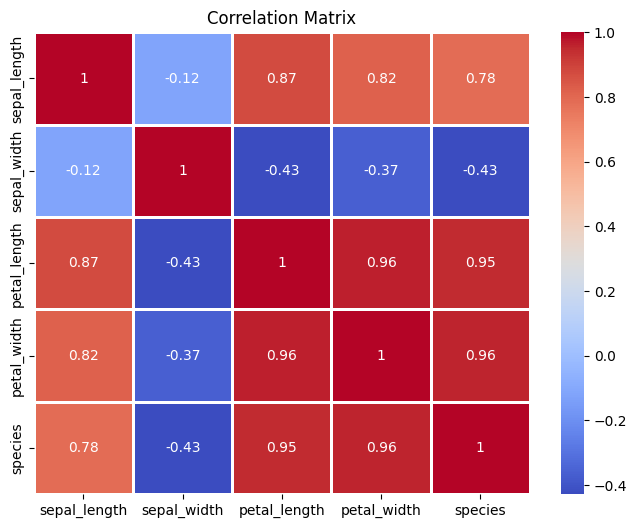

In [24]:
#CORRELATION ANALYSIS
df_corr = df.copy()

le = LabelEncoder()
df_corr['species'] = le.fit_transform(df_corr['species'])

plt.figure(figsize=(8,6))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title("Correlation Matrix")
plt.show()


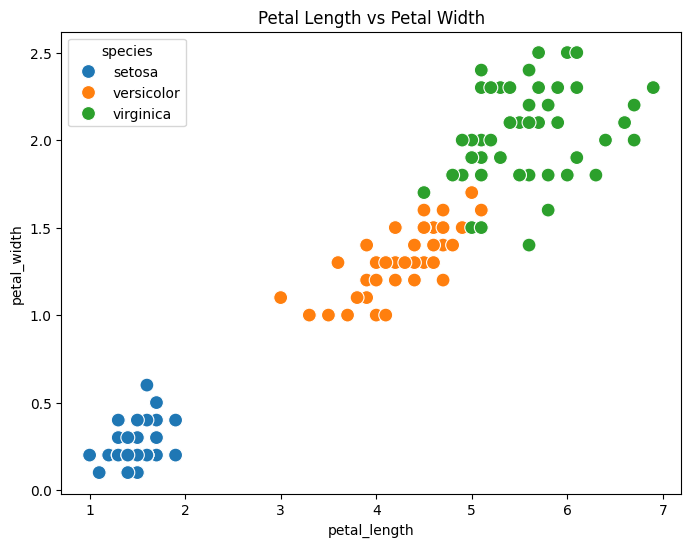

In [26]:
#SCATTER PLOT
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df,
    s=100
)

plt.title("Petal Length vs Petal Width")
plt.show()

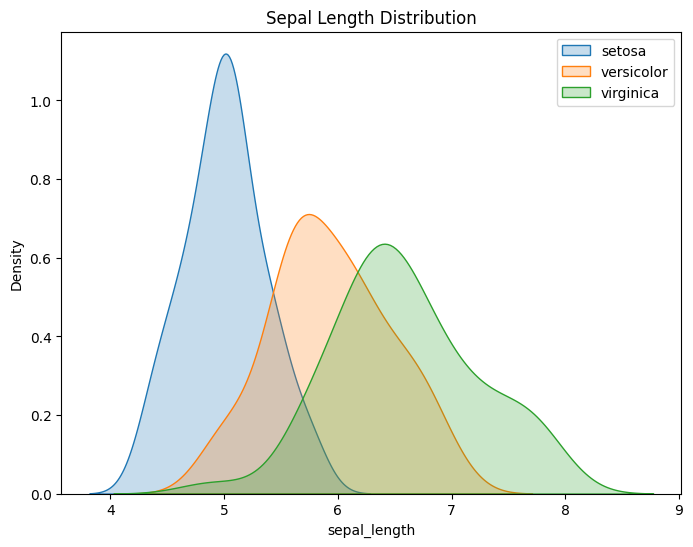

In [14]:
#KDE DISTRIBUTION PLOT

plt.figure(figsize=(8,6))

for species in df['species'].unique():

    subset = df[df['species'] == species]

    sns.kdeplot(
        subset['sepal_length'],
        label=species,
        fill=True
    )

plt.title("Sepal Length Distribution")
plt.legend()
plt.show()

In [27]:
# Convert target column to numeric labels
df['species'] = le.fit_transform(df['species'])

In [28]:
#SPLIT DATA FOR TRAINING AND TESTING
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:
#TRAIN MODEL
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
#PREDICTIONS
y_pred = model.predict(X_test)

In [31]:
#MODEL EVALUATION
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [38]:
# CHECK OVERFITTING

# Training accuracy
train_accuracy = model.score(X_train, y_train)

# Testing accuracy
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

# Check overfitting condition
if train_accuracy > test_accuracy:
    print("\nModel may be slightly overfitting.")
else:
    print("\nModel is generalizing well.")

Training Accuracy : 1.0
Testing Accuracy  : 1.0

Model is generalizing well.


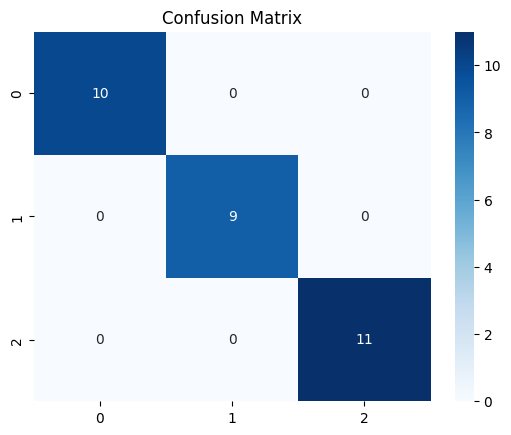

In [32]:
#CONFUSION MATRIX
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

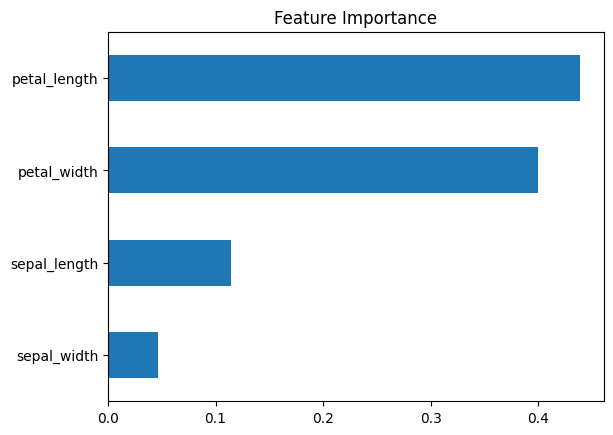

In [33]:
#FEATURE IMPORTANCE
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [35]:
print("FINAL INSIGHTS")
print("===================================")

print("1. Petal length and petal width are highly correlated.")

print("2. Setosa species is clearly separable from other species.")

print("3. Virginica flowers generally have larger petal dimensions.")

print("4. The dataset contains no missing values.")

print("5. Random Forest model achieved very high accuracy.")

print("6. Petal-related features are most important for prediction.")

print("7. Sepal features show more overlap between species.")

print("8. Dataset is balanced across all species.")


FINAL INSIGHTS
1. Petal length and petal width are highly correlated.
2. Setosa species is clearly separable from other species.
3. Virginica flowers generally have larger petal dimensions.
4. The dataset contains no missing values.
5. Random Forest model achieved very high accuracy.
6. Petal-related features are most important for prediction.
7. Sepal features show more overlap between species.
8. Dataset is balanced across all species.


In [36]:
print("PROJECT CONCLUSION")
print("===================================")

print("""

This Exploratory Data Analysis (EDA) project on the Iris dataset
helped identify important feature relationships and classification patterns.

Visualizations such as pairplots, heatmaps, histograms, scatter plots,
and boxplots provided deeper understanding of the dataset.

The Random Forest classifier performed efficiently with high accuracy,
showing that petal measurements are strong indicators of flower species.

""")

PROJECT CONCLUSION


This Exploratory Data Analysis (EDA) project on the Iris dataset
helped identify important feature relationships and classification patterns.

Visualizations such as pairplots, heatmaps, histograms, scatter plots,
and boxplots provided deeper understanding of the dataset.

The Random Forest classifier performed efficiently with high accuracy,
showing that petal measurements are strong indicators of flower species.


